In [181]:
#julia -t 4

using Plots
using Random, Statistics, Distributions
using SparseArrays
using LinearAlgebra
using DifferentialEquations
using StatsPlots 

using Statistics 
using Distributions, Random, Plots, StatsBase  
using Base.Threads



include("../Project_with_Jon/GPs.jl")
include("../Project_with_Jon/functions.jl")
include("../Project_with_Jon/myfuncs.jl")
include("../Project_with_Jon/integrators.jl")
include("../Project_with_Jon/util_shoji.jl")


simulate_pf_selforg (generic function with 1 method)

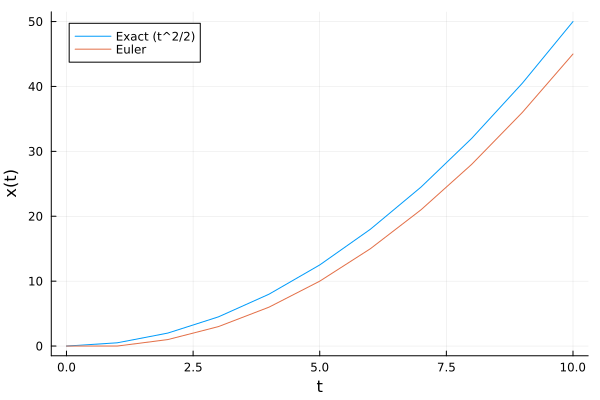

In [182]:
u0 = 0.0
dt = 1.0
T = 10
tspan = 0:dt:T

function reaction(u, p, t)
    return t
end

sol = exact(reaction, u0, tspan, Tsit5(), 1e-10, 1e-10)

numsol, _ = numerical_integration(
    reaction,
    Euler,
    u0,
    dt,
    length(tspan),
    1
)

plot(tspan, sol,
    label="Exact (t^2/2)",
    xlabel="t",
    ylabel="x(t)"
)

plot!(tspan, numsol,
    label="Euler"
)



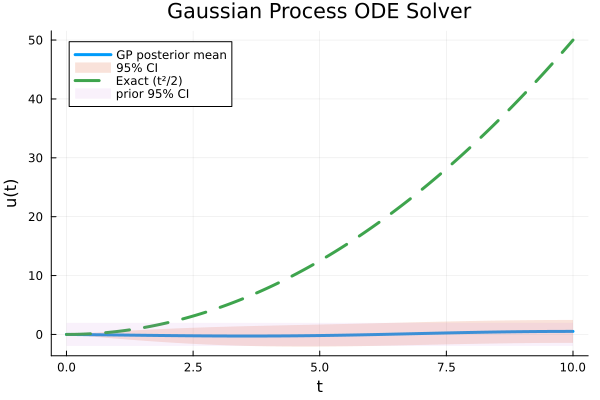

y:[0.0, 0.0, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0]


In [183]:
using LinearAlgebra
using Plots



# =====================================================
# Cov(L_i,L_j)
#
# L_i u =
# (u(t_i+dt)-u(t_i))/dt
# =====================================================

function K_LL(ts; dt, ℓ=1.0, σf=1.0)

    n = length(ts)

    K = zeros(n,n)

    for i in 1:n
        for j in 1:n

            ti = ts[i]
            tj = ts[j]

            K[i,j] =
                (
                    rbf_kernel(ti+dt,tj+dt; ℓ=ℓ, σf=σf)
                    -
                    rbf_kernel(ti+dt,tj; ℓ=ℓ, σf=σf)
                    -
                    rbf_kernel(ti,tj+dt; ℓ=ℓ, σf=σf)
                    +
                    rbf_kernel(ti,tj; ℓ=ℓ, σf=σf)
                ) / dt^2

        end
    end

    K
end

# =====================================================
# Observation covariance
#
# observations:
#
# [u(0),
#  L0u,
#  L1u,
#  ...]
# =====================================================

function build_observation_covariance(ts;
                                      dt,
                                      ℓ,
                                      σf)

    n = length(ts)

    K = zeros(n+1,n+1)

    #
    # Cov(u(0),u(0))
    #

    K[1,1] =
        rbf_kernel(
            0.0,
            0.0;
            ℓ=ℓ,
            σf=σf
        )

    #
    # Cov(u(0),Lj)
    #

    for j in 1:n

        tj = ts[j]

        K[1,j+1] =
            (
                rbf_kernel(
                    0.0,
                    tj+dt;
                    ℓ=ℓ,
                    σf=σf
                )
                -
                rbf_kernel(
                    0.0,
                    tj;
                    ℓ=ℓ,
                    σf=σf
                )
            ) / dt

        K[j+1,1] =
            K[1,j+1]

    end

    #
    # Cov(Li,Lj)
    #

    K[2:end,2:end] .=
        K_LL(
            ts;
            dt=dt,
            ℓ=ℓ,
            σf=σf
        )

    K
end

# =====================================================
# Cov(u(t),L_j)
# =====================================================

function K_starL(X_test,
                 ts;
                 dt,
                 ℓ=1.0,
                 σf=1.0)

    m = length(X_test)
    n = length(ts)

    K = zeros(m,n)

    for i in 1:m
        for j in 1:n

            t = X_test[i]
            tj = ts[j]

            K[i,j] =
                (
                    rbf_kernel(t,tj+dt; ℓ=ℓ, σf=σf)
                    -
                    rbf_kernel(t,tj; ℓ=ℓ, σf=σf)
                ) / dt

        end
    end

    K
end



# =====================================================
# Cross covariance
#
# Cov(u(t), observations)
# =====================================================

function build_cross_covariance(X_test,
                                ts;
                                dt,
                                ℓ,
                                σf)

    m = length(X_test)
    n = length(ts)

    K = zeros(m,n+1)

    #
    # Cov(u(t),u(0))
    #

    for i in 1:m

        K[i,1] =
            rbf_kernel(
                X_test[i],
                0.0;
                ℓ=ℓ,
                σf=σf
            )

    end

    #
    # Cov(u(t),Lj)
    #

    K[:,2:end] .=
        K_starL(
            X_test,
            ts;
            dt=dt,
            ℓ=ℓ,
            σf=σf
        )

    K
end

# =====================================================
# ODE
#
# u'(t)=t
#
# exact:
# u(t)=t²/2
# =====================================================

dt = 1.0

t_obs =
    collect(0:dt:8)

rhs =
    collect(t_obs)

#
# observations:
#
# u(0)=0
#
# (u(t_i+dt)-u(t_i))/dt = t_i
#

y =
    vcat(
        [0.0],
        rhs
    )

println("y:", y)

# =====================================================
# GP hyperparameters
# =====================================================

ℓ = 3.0
σf = 1.0

# =====================================================
# Posterior
# =====================================================

X_test =
    collect(
        range(
            0,
            10,
            length=500
        )
    )

K =
    build_observation_covariance(
        t_obs;
        dt=dt,
        ℓ=ℓ,
        σf=σf
    )

#K += 1e-10I


#Observation Noise
K[2:end,2:end] += 10 .* I

Ks =
    build_cross_covariance(
        X_test,
        t_obs;
        dt=dt,
        ℓ=ℓ,
        σf=σf
    )

Kss =
    kernel_matrix(
        X_test,
        X_test;
        ℓ=ℓ,
        σf=σf
    )

μ =
    Ks * (K \ y)

Σ =
    Kss -
    Ks * (K \ Ks')

std =
    sqrt.(max.(diag(Σ),0))

# =====================================================
# Exact solution
# =====================================================

u_exact(t) =
    t^2 / 2


# =====================================================
# Plot
# =====================================================

plot(
    X_test,
    μ,
    lw=3,
    label="GP posterior mean"
)

plot!(
    X_test,
    μ .+ 1.96 .* std,
    fillrange=
        μ .- 1.96 .* std,
    fillalpha=0.2,
    linealpha=0,
    label="95% CI"
)

plot!(
    X_test,
    u_exact.(X_test),
    lw=3,
    ls=:dash,
    label="Exact (t²/2)"
)

μ_prior = zeros(length(X_test))

Kss = kernel_matrix(
    X_test,
    X_test;
    ℓ=ℓ,
    σf=σf
)

std_prior = sqrt.(diag(Kss))


plot!(
    X_test,
    1.96 .* std_prior,
    fillrange = -1.96 .* std_prior,
    fillalpha=0.1,
    linealpha=0,
    label="prior 95% CI"
)

xlabel!("t")
ylabel!("u(t)")
title!("Gaussian Process ODE Solver")

display(current())

In [184]:
ℓ_grid = [0.1, 0.5, 1.0, 3.0, 5.0]

σf = 1.0   # 固定（必要ならここもグリッド化可能）

scores = zeros(length(ℓ_grid))

for (k, ℓ) in enumerate(ℓ_grid)
    scores[k] = log_marginal_extended(t_obs, y;
                                       dt=dt,
                                       ℓ=ℓ,
                                       σf=σf)
end

best_idx = argmax(scores)
best_ℓ = ℓ_grid[best_idx]

println("best ℓ = ", best_ℓ)
println("scores = ", scores)

best ℓ = 1.0
scores = [-1455.1893853320466, -1220.9039249220095, -825.2332058402608, -1846.1048654027056, -6226.922575246054]


y:[0.0, 0.0, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0]
m_y:[20.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
m_x:(500,)
 Ks * (K \ (y-m_y)):(500,)


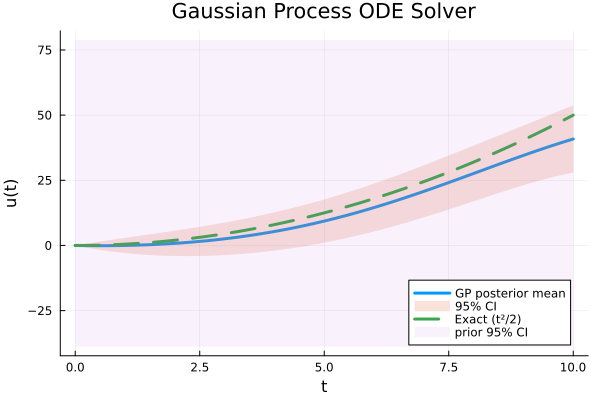

In [186]:
using LinearAlgebra
using Plots



ℓ = 5.0
σf = 30.0
prior_mean = 20.0
obs_noise = 4.0

# =====================================================
# Cov(L_i,L_j)
#
# L_i u =
# (u(t_i+dt)-u(t_i))/dt
# =====================================================

function K_LL(ts; dt, ℓ=1.0, σf=1.0)

    n = length(ts)

    K = zeros(n,n)

    for i in 1:n
        for j in 1:n

            ti = ts[i]
            tj = ts[j]

            K[i,j] =
                (
                    rbf_kernel(ti+dt,tj+dt; ℓ=ℓ, σf=σf)
                    -
                    rbf_kernel(ti+dt,tj; ℓ=ℓ, σf=σf)
                    -
                    rbf_kernel(ti,tj+dt; ℓ=ℓ, σf=σf)
                    +
                    rbf_kernel(ti,tj; ℓ=ℓ, σf=σf)
                ) / dt^2

        end
    end

    K
end

# =====================================================
# Observation covariance
#
# observations:
#
# [u(0),
#  L0u,
#  L1u,
#  ...]
# =====================================================

function build_observation_covariance(ts;
                                      dt,
                                      ℓ,
                                      σf)

    n = length(ts)

    K = zeros(n+1,n+1)

    #
    # Cov(u(0),u(0))
    #

    K[1,1] =
        rbf_kernel(
            0.0,
            0.0;
            ℓ=ℓ,
            σf=σf
        )

    #
    # Cov(u(0),Lj)
    #

    for j in 1:n

        tj = ts[j]

        K[1,j+1] =
            (
                rbf_kernel(
                    0.0,
                    tj+dt;
                    ℓ=ℓ,
                    σf=σf
                )
                -
                rbf_kernel(
                    0.0,
                    tj;
                    ℓ=ℓ,
                    σf=σf
                )
            ) / dt

        K[j+1,1] =
            K[1,j+1]

    end

    #
    # Cov(Li,Lj)
    #

    K[2:end,2:end] .=
        K_LL(
            ts;
            dt=dt,
            ℓ=ℓ,
            σf=σf
        )

    K
end

# =====================================================
# Cov(u(t),L_j)
# =====================================================

function K_starL(X_test,
                 ts;
                 dt,
                 ℓ=1.0,
                 σf=1.0)

    m = length(X_test)
    n = length(ts)

    K = zeros(m,n)

    for i in 1:m
        for j in 1:n

            t = X_test[i]
            tj = ts[j]

            K[i,j] =
                (
                    rbf_kernel(t,tj+dt; ℓ=ℓ, σf=σf)
                    -
                    rbf_kernel(t,tj; ℓ=ℓ, σf=σf)
                ) / dt

        end
    end

    K
end



# =====================================================
# Cross covariance
#
# Cov(u(t), observations)
# =====================================================

function build_cross_covariance(X_test,
                                ts;
                                dt,
                                ℓ,
                                σf)

    m = length(X_test)
    n = length(ts)

    K = zeros(m,n+1)

    #
    # Cov(u(t),u(0))
    #

    for i in 1:m

        K[i,1] =
            rbf_kernel(
                X_test[i],
                0.0;
                ℓ=ℓ,
                σf=σf
            )

    end

    #
    # Cov(u(t),Lj)
    #

    K[:,2:end] .=
        K_starL(
            X_test,
            ts;
            dt=dt,
            ℓ=ℓ,
            σf=σf
        )

    K
end

# =====================================================
# ODE
#
# u'(t)=t
#
# exact:
# u(t)=t²/2
# =====================================================

dt = 1.0

t_obs =
    collect(0:dt:8)

rhs =
    collect(t_obs)

#
# observations:
#
# u(0)=0
#
# (u(t_i+dt)-u(t_i))/dt = t_i
#

y =
    vcat(
        [0.0],
        rhs
    )

#y .-= prior_mean

println("y:", y)


# =====================================================
# Posterior
# =====================================================

X_test =
    collect(
        range(
            0,
            10,
            length=500
        )
    )

K =
    build_observation_covariance(
        t_obs;
        dt=dt,
        ℓ=ℓ,
        σf=σf
    )

#K += 1e-10I


#Observation Noise
K[2:end,2:end] += obs_noise .* I

Ks =
    build_cross_covariance(
        X_test,
        t_obs;
        dt=dt,
        ℓ=ℓ,
        σf=σf
    )

Kss =
    kernel_matrix(
        X_test,
        X_test;
        ℓ=ℓ,
        σf=σf
    )

m_y = vcat([prior_mean],  zeros(length(t_obs)))
println("m_y:", m_y)
m_x = fill(prior_mean, length(X_test))
println("m_x:", m_x.size)
println(" Ks * (K \\ (y-m_y)):", (Ks * (K \ (y-m_y))).size)

μ =   
 m_x + Ks * (K \ (y-m_y))




Σ =
    Kss -
    Ks * (K \ Ks')

std =
    sqrt.(max.(diag(Σ),0))

# =====================================================
# Exact solution
# =====================================================

u_exact(t) =
    t^2 / 2


# =====================================================
# Plot
# =====================================================

plot(
    X_test,
    μ,
    lw=3,
    label="GP posterior mean"
)

plot!(
    X_test,
    μ .+ 1.96 .* std,
    fillrange=
        μ .- 1.96 .* std,
    fillalpha=0.2,
    linealpha=0,
    label="95% CI"
)

plot!(
    X_test,
    u_exact.(X_test),
    lw=3,
    ls=:dash,
    label="Exact (t²/2)"
)

μ_prior = zeros(length(X_test))

Kss = kernel_matrix(
    X_test,
    X_test;
    ℓ=ℓ,
    σf=σf
)

std_prior = sqrt.(diag(Kss))


μ_prior = fill(prior_mean, length(X_test))

plot!(
    X_test,
    μ_prior .+ 1.96 .* std_prior,
    fillrange = μ_prior .- 1.96 .* std_prior,
    fillalpha = 0.1,
    linealpha = 0,
    label = "prior 95% CI"
)

xlabel!("t")
ylabel!("u(t)")
title!("Gaussian Process ODE Solver")

display(current())

In [187]:
ℓ_grid = [0.1, 0.5, 1.0, 3.0, 5.0]
prior_mean_grid = [-40, -30, -20, -10, 0.0, 10.0, 20.0, 30.0, 40.0]

σf = 1.0

scores = zeros(length(ℓ_grid), length(prior_mean_grid))

for (i, ℓ) in enumerate(ℓ_grid)
    for (j, m0) in enumerate(prior_mean_grid)

        scores[i, j] = log_marginal_extended2(
            t_obs,
            y;
            dt=dt,
            ℓ=ℓ,
            σf=σf,
            prior_mean=m0
        )

    end
end

# ==========================================
# 表形式で表示
# ==========================================



print(rpad("ℓ \\ m0", 10))

for m0 in prior_mean_grid
    print(rpad(string(m0), 14))
end
println()

println("-"^(10 + 14*length(prior_mean_grid)))

for (i, ℓ) in enumerate(ℓ_grid)

    print(rpad(string(ℓ), 10))

    for j in eachindex(prior_mean_grid)
        print(rpad(string(round(scores[i,j], digits=4)), 14))
    end

    println()

end

# ==========================================
# 最良パラメータ
# ==========================================

best_idx = argmax(scores)
best_i, best_j = Tuple(CartesianIndices(scores)[best_idx])

best_ℓ = ℓ_grid[best_i]
best_prior_mean = prior_mean_grid[best_j]

println()
println("Best parameters")
println("----------------")
println("best ℓ          = ", best_ℓ)
println("best prior_mean = ", best_prior_mean)
println("best score      = ", scores[best_i, best_j])

ℓ \ m0    -40.0         -30.0         -20.0         -10.0         0.0           10.0          20.0          30.0          40.0          
----------------------------------------------------------------------------------------------------------------------------------------
0.1       -14255.1894   -9555.1894    -5855.1894    -3155.1894    -1455.1894    -755.1894     -1055.1894    -2355.1894    -4655.1894    
0.5       -11583.8296   -7784.5193    -4790.9282    -2603.0565    -1220.9039    -644.4707     -873.7567     -1908.7619    -3749.4865    
1.0       -6802.9625    -4628.6157    -2907.5453    -1639.7511    -825.2332     -463.9916     -556.0263     -1101.3372    -2099.9245    
3.0       -6513.9038    -4939.6064    -3636.8741    -2605.7069    -1846.1049    -1358.0679    -1141.5961    -1196.6893    -1523.3477    
5.0       -12778.3486   -10757.7186   -8992.2709    -7482.0056    -6226.9226    -5227.0219    -4482.3036    -3992.7676    -3758.4139    

Best parameters
----------------
best ℓ 

In [189]:
ℓ_grid = [0.1, 0.5, 1.0, 3.0, 5.0]

σf_grid = [0.01, 0.03, 0.1, 0.3, 1, 3, 10, 30, 100]

prior_mean_grid = [0.0,10.0, 20.0, 30.0, 40.0]

scores = zeros(
    length(ℓ_grid),
    length(σf_grid),
    length(prior_mean_grid)
)

# ==========================================
# Grid Search
# ==========================================

for (i, ℓ) in enumerate(ℓ_grid)
    for (j, σf) in enumerate(σf_grid)
        for (k, m0) in enumerate(prior_mean_grid)

            scores[i,j,k] =
                log_marginal_extended2(
                    t_obs,
                    y;
                    dt=dt,
                    ℓ=ℓ,
                    σf=σf,
                    prior_mean=m0,
                    prior_noise = 4.0
                )

        end
    end
end

# ==========================================
# 全スコア表示
# ==========================================

for (j, σf) in enumerate(σf_grid)

    println()
    println("========================================")
    println("σf = ", σf)
    println("========================================")

    print(rpad("ℓ \\ m0", 10))

    for m0 in prior_mean_grid
        print(rpad(string(m0), 14))
    end
    println()

    println("-"^(10 + 14*length(prior_mean_grid)))

    for (i, ℓ) in enumerate(ℓ_grid)

        print(rpad(string(ℓ), 10))

        for k in eachindex(prior_mean_grid)

            print(
                rpad(
                    string(round(scores[i,j,k], digits=4)),
                    14
                )
            )

        end

        println()

    end
end

# ==========================================
# Best parameters
# ==========================================

best_linear_idx = argmax(scores)

best_i,
best_j,
best_k =
    Tuple(
        CartesianIndices(scores)[best_linear_idx]
    )

best_ℓ = ℓ_grid[best_i]
best_σf = σf_grid[best_j]
best_prior_mean = prior_mean_grid[best_k]

println()
println("Best parameters")
println("----------------")
println("best ℓ          = ", best_ℓ)
println("best σf         = ", best_σf)
println("best prior_mean = ", best_prior_mean)
println("best score      = ", scores[best_i,best_j,best_k])


σf = 0.01
ℓ \ m0    0.0           10.0          20.0          30.0          40.0          
--------------------------------------------------------------------------------
0.1       -36.3225      -500048.8222  -2.0000863212e6-4.5001488195e6-8.0002363173e6
0.5       -36.3225      -500045.5565  -2.0000739368e6-4.5001214636e6-8.0001881367e6
1.0       -36.3224      -500039.3439  -2.0000521751e6-4.500074816e6-8.0001072666e6
3.0       -36.3224      -500030.2564  -2.0000278307e6-4.5000290453e6-8.0000339002e6
5.0       -36.3225      -500028.255   -2.0000221933e6-4.5000181375e6-8.0000160875e6

σf = 0.03
ℓ \ m0    0.0           10.0          20.0          30.0          40.0          
--------------------------------------------------------------------------------
0.1       -37.421       -55605.4732   -222309.6309  -500149.8941  -889126.2627  
0.5       -37.4208      -55602.2084   -222297.2507  -500122.5476  -889078.0993  
1.0       -37.4199      -55595.9961   -222275.4923  -500075.9086  -888997